# Verification of the Samoilov-Plyasunov-Arkin noise-driven futile cycle

This notebook verifies the curated BNGL collection at two levels.

1. **Model specification.** A fresh BioNetGen run of each `.bngl` file is
   compared with the committed reference output; its deterministic trajectory is
   compared with an independent SciPy integration of Eqs. S5 in the Supporting
   Text of Samoilov et al. (2005); and its stochastic trajectory statistics are
   compared with an independent pure-Python Gillespie implementation written
   directly from Expressions 7 and 8, not from the BioNetGen network.
2. **Reported simulation data.** The deterministic steady state is compared with
   the fixed point reported verbatim in Supporting Text Section I, and the
   stochastic trajectory statistics are compared with the digitized Fig. 3A
   trace and its `E+(t)` inset.

Three files are checked:

| file | mechanism |
|---|---|
| `..._samoilov2005.bngl` (primary) | Expressions 7 and 8, with `k_21` per ordered (converted, catalyst) pair, as BioNetGen writes it (ODE flux `k_21*N^2`, propensity `k_21*N*(N-1)`) |
| `..._unordered_pair.bngl` | identical except that `k_21` is read per unordered pair (flux `k_21*N^2/2`, propensity `k_21*N*(N-1)/2`) |
| `..._no_driver.bngl` | Expression 7 only, external driver deleted |

The source paper turns out to be ambiguous about the driver step: its reported
deterministic fixed point implies the first reading, while its published
Fig. 3A trace statistics imply the second. Sections 3 and 5 quantify
both sides of that ambiguity; the two files bracket it.

Stochastic comparisons never use pointwise trajectory errors. A single 10 s
trajectory contains only a handful of switching events, so every published
statistic is compared with the distribution of the same statistic over a
64-replicate seeded BioNetGen ensemble.

In [1]:
import os
import subprocess
import tempfile
import time
from concurrent.futures import ThreadPoolExecutor
from math import log
from pathlib import Path
from random import Random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.signal import argrelmax
from scipy.stats import gaussian_kde

MODEL_ID = "noise_induced_bistable_futile_cycle_samoilov2005"
VARIANTS = {
    "primary": MODEL_ID,
    "unordered_pair": f"{MODEL_ID}_unordered_pair",
    "no_driver": f"{MODEL_ID}_no_driver",
}
DRIVEN = ["primary", "unordered_pair"]

MODEL_DIR = Path.cwd()
if not (MODEL_DIR / f"{MODEL_ID}.bngl").is_file():
    candidate = Path("models") / MODEL_ID
    if (candidate / f"{MODEL_ID}.bngl").is_file():
        MODEL_DIR = candidate.resolve()
    else:
        raise FileNotFoundError(f"Run this notebook from {MODEL_ID}/ or the repository root.")
REFERENCE_DIR = MODEL_DIR / "reference"

# Rate constants and initial molecule counts, Fig. 3 caption of Samoilov et al. (2005)
KP1, KP2, KP3 = 40.0, 1.0e4, 1.0e4      # k+1, k+2, k+3
KM1, KM2, KM3 = 200.0, 100.0, 5.0e3     # k-1, k-2, k-3
K21, KM21, K22, KM22 = 10.0, 5.0, 10.0, 0.2
INIT_DRIVEN = dict(X=0.0, Xs=2000.0, Cp=0.0, Cm=0.0, Ep=20.0, Em=50.0, N=10.0)
# The undriven control seeds the whole conserved E+ + C+ + N pool as free enzyme
INIT_NO_DRIVER = dict(INIT_DRIVEN, Ep=30.0, N=0.0)
SPECIES = ["X", "Xs", "Cp", "Cm", "Ep", "Em", "N"]
OBS_OF = {"X": "Obs_X", "Xs": "Obs_X_star", "Cp": "Obs_C_plus", "Cm": "Obs_C_minus",
          "Ep": "Obs_E_plus", "Em": "Obs_E_minus", "N": "Obs_N"}

BNG_SEED = 406841
T_END, N_STEPS = 10.0, 2000
T_END_ODE, N_STEPS_ODE = 200.0, 2000
BURN_IN = 0.05            # discard the t = 0 initial-condition transient
ENSEMBLE_SIZE = 64        # BioNetGen SSA replicates per model
INDEP_REPLICATES = 16     # independent pure-Python Gillespie replicates per model
FINE_REPLICATES = 8       # replicates sampled finely enough for the E+ envelope
FINE_DT = 0.0005          # s
LOW_STATE_CUT = 190.0     # molecules; separates the low and high X* states

print(f"Model directory: {MODEL_DIR}")
print(f"Files: {', '.join(sorted(p.name for p in MODEL_DIR.glob('*.bngl')))}")

Model directory: /Users/l119605/Code/BNGL-Models/models/noise_induced_bistable_futile_cycle_samoilov2005
Files: noise_induced_bistable_futile_cycle_samoilov2005.bngl, noise_induced_bistable_futile_cycle_samoilov2005_no_driver.bngl, noise_induced_bistable_futile_cycle_samoilov2005_unordered_pair.bngl


## 1. Fresh BioNetGen execution against the committed reference

Each `.bngl` file is copied to a temporary directory and executed there. The
committed reference set covers both the active SSA protocol and the commented
ODE protocol, so the copy has the ODE protocol uncommented before it is run;
nothing else about the file is changed. Agreement rules follow
`skills/curate-model/SKILL.md`: `.net` files must match structurally after comments and
whitespace are stripped, and `.gdat` values must agree to a relative error of
1e-3 or an absolute error of `1e-6 * max(|column|)`.

In [2]:
def find_bng2():
    candidates = [
        os.environ.get("BNG2_PL"),
        str(Path(os.environ["BNGPATH"]) / "BNG2.pl") if os.environ.get("BNGPATH") else None,
        str(Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"),
        str(Path.home() / "Code" / "bionetgen" / "bng2" / "BNG2.pl"),
    ]
    for candidate in candidates:
        if candidate and Path(candidate).is_file():
            return Path(candidate).resolve()
    raise FileNotFoundError(
        "Set BNG2_PL to a BioNetGen 2.9.3 BNG2.pl executable before running this notebook."
    )


def enable_ode_protocol(text):
    """Uncomment the commented-out ODE protocol, leaving everything else alone."""
    out, in_block = [], False
    for line in text.splitlines():
        if line.strip().startswith("# Deterministic relaxation"):
            in_block = True
            out.append(line)
            continue
        if in_block:
            if (line.startswith("#  resetConcentrations()")
                    or line.startswith('#  simulate({method=>"ode"')
                    or line.startswith("#    atol=")):
                out.append(line[1:])
                if line.startswith("#    atol="):
                    in_block = False
                continue
            in_block = False
        out.append(line)
    return "\n".join(out) + "\n"


def net_signature(path):
    """Structural content of a .net file: comments and whitespace removed."""
    rows = []
    for raw in Path(path).read_text().splitlines():
        stripped = raw.split("#")[0].strip()
        if stripped:
            rows.append(" ".join(stripped.split()))
    return rows


def read_gdat(path):
    header = Path(path).read_text().splitlines()[0].split()[1:]
    return header, np.loadtxt(path)


def gdat_max_error(path_a, path_b):
    """Worst (relative, absolute-tolerance-scaled) disagreement between two .gdat files."""
    head_a, a = read_gdat(path_a)
    head_b, b = read_gdat(path_b)
    assert head_a == head_b and a.shape == b.shape, (head_a, head_b, a.shape, b.shape)
    worst = 0.0
    for j in range(a.shape[1]):
        atol = 1e-6 * max(np.abs(a[:, j]).max(), 1.0)
        err = np.abs(a[:, j] - b[:, j])
        rel = err / np.maximum(np.abs(a[:, j]), 1e-300)
        worst = max(worst, float(np.min([rel, err / atol * 1e-3], axis=0).max()))
    return worst


bng2 = find_bng2()
runner = bng2.parent / "bin" / "run_network"
assert runner.is_file(), f"run_network not found beside {bng2}"
print(f"BioNetGen: {bng2}")

WORK = Path(tempfile.mkdtemp(prefix="samoilov2005_"))
fresh_rows = []
for key, stem in VARIANTS.items():
    src = MODEL_DIR / f"{stem}.bngl"
    (WORK / src.name).write_text(enable_ode_protocol(src.read_text()))
    proc = subprocess.run(["perl", str(bng2), src.name], cwd=WORK,
                          capture_output=True, text=True, timeout=900)
    assert proc.returncode == 0, proc.stdout[-3000:] + proc.stderr[-2000:]
    for suffix in [".net", "_ssa.net", "_ode.net"]:
        name = f"{stem}{suffix}"
        same = net_signature(WORK / name) == net_signature(REFERENCE_DIR / name)
        fresh_rows.append((name, "structural match" if same else "MISMATCH", same))
    for suffix in ["_ssa.gdat", "_ode.gdat"]:
        name = f"{stem}{suffix}"
        err = gdat_max_error(WORK / name, REFERENCE_DIR / name)
        fresh_rows.append((name, f"max error {err:.2e}", err <= 1e-3))

fresh = pd.DataFrame(fresh_rows, columns=["file", "result", "ok"])
print(fresh.to_string(index=False))
assert bool(fresh["ok"].all()), "fresh BioNetGen output does not reproduce the committed reference"
print("\nPASS: all three models reproduce their committed reference output.")

BioNetGen: /Users/l119605/Simulations/BioNetGen-2.9.3/BNG2.pl


                                                                    file             result   ok
                    noise_induced_bistable_futile_cycle_samoilov2005.net   structural match True
                noise_induced_bistable_futile_cycle_samoilov2005_ssa.net   structural match True
                noise_induced_bistable_futile_cycle_samoilov2005_ode.net   structural match True
               noise_induced_bistable_futile_cycle_samoilov2005_ssa.gdat max error 0.00e+00 True
               noise_induced_bistable_futile_cycle_samoilov2005_ode.gdat max error 0.00e+00 True
     noise_induced_bistable_futile_cycle_samoilov2005_unordered_pair.net   structural match True
 noise_induced_bistable_futile_cycle_samoilov2005_unordered_pair_ssa.net   structural match True
 noise_induced_bistable_futile_cycle_samoilov2005_unordered_pair_ode.net   structural match True
noise_induced_bistable_futile_cycle_samoilov2005_unordered_pair_ssa.gdat max error 0.00e+00 True
noise_induced_bistable_futile_

## 2. Independent deterministic implementation (Eqs. S5)

The Supporting Text writes the extended system as

$$\frac{dX_\pm}{dt}=k_{\pm2}C_\pm+k_{\mp3}C_\mp-k_{\pm1}E_\pm X_\pm,\qquad
\frac{dC_\pm}{dt}=k_{\pm1}E_\pm X_\pm-(k_{\pm2}+k_{\pm3})C_\pm,$$

$$\frac{dE_\pm}{dt}=(k_{\pm2}+k_{\pm3})C_\pm-k_{\pm1}E_\pm X_\pm-\frac{1\pm1}{2}\frac{dN}{dt},
\qquad \frac{dN}{dt}=(k_{-21}N+k_{-22})E_+-(k_{21}N+k_{22})N,$$

with $X_+\equiv X$ and $X_-\equiv X^*$. These equations are transcribed directly
into Python below and integrated with `solve_ivp`; nothing is taken from the
BioNetGen network. The driver flux enters as $k_{21}N^2$ for the primary model
and $k_{21}N^2/2$ for the unordered-pair variant, and the whole driver term is
dropped for the undriven control.

In [3]:
def eqs_s5(_t, state, k21=K21, driver=True):
    X, Xs, Cp, Cm, Ep, Em, N = state
    bind_p, unbind_p, cat_p = KP1 * Ep * X, KP2 * Cp, KP3 * Cp
    bind_m, unbind_m, cat_m = KM1 * Em * Xs, KM2 * Cm, KM3 * Cm
    dN = (KM21 * N + KM22) * Ep - (k21 * N + K22) * N if driver else 0.0
    return [
        unbind_p + cat_m - bind_p,                 # dX/dt
        unbind_m + cat_p - bind_m,                 # dX*/dt
        bind_p - unbind_p - cat_p,                 # dC+/dt
        bind_m - unbind_m - cat_m,                 # dC-/dt
        unbind_p + cat_p - bind_p - dN,            # dE+/dt
        unbind_m + cat_m - bind_m,                 # dE-/dt
        dN,                                        # dN/dt
    ]


ODE_SETTINGS = {
    "primary": dict(k21=K21, driver=True, init=INIT_DRIVEN),
    "unordered_pair": dict(k21=K21 / 2.0, driver=True, init=INIT_DRIVEN),
    "no_driver": dict(k21=K21, driver=False, init=INIT_NO_DRIVER),
}

scipy_solutions, ode_rows = {}, []
for key, stem in VARIANTS.items():
    cfg = ODE_SETTINGS[key]
    header, bng = read_gdat(REFERENCE_DIR / f"{stem}_ode.gdat")
    y0 = [cfg["init"][s] for s in SPECIES]
    sol = solve_ivp(eqs_s5, (0.0, T_END_ODE), y0, t_eval=bng[:, 0], method="LSODA",
                    rtol=1e-11, atol=1e-9, args=(cfg["k21"], cfg["driver"]))
    assert sol.success, sol.message
    scipy_solutions[key] = sol
    worst, worst_obs = 0.0, ""
    for name, sp in [(OBS_OF[s], s) for s in SPECIES if OBS_OF[s] in header]:
        ref = bng[:, header.index(name)]
        mine = sol.y[SPECIES.index(sp)]
        rel = np.abs(mine - ref) / np.maximum(np.abs(ref), 1e-8)
        if rel.max() > worst:
            worst, worst_obs = float(rel.max()), name
    l2 = float(np.linalg.norm(sol.y[1] - bng[:, header.index("Obs_X_star")])
               / np.linalg.norm(bng[:, header.index("Obs_X_star")]))
    ode_rows.append((key, worst, worst_obs, l2))

ode = pd.DataFrame(ode_rows, columns=["model", "max_rel_err", "worst_observable", "X*_rel_L2"])
print(ode.to_string(index=False, float_format=lambda v: f"{v:.3e}"))
assert bool((ode["max_rel_err"] < 1e-6).all()), "BNG ODE and the independent Eqs. S5 solution disagree"
print("\nPASS: BioNetGen reproduces the independent Eqs. S5 integration to better than 1e-6 relative.")

         model  max_rel_err worst_observable  X*_rel_L2
       primary    7.507e-10            Obs_N  2.405e-11
unordered_pair    5.042e-10            Obs_N  1.519e-11
     no_driver    2.659e-10       Obs_X_star  7.207e-12

PASS: BioNetGen reproduces the independent Eqs. S5 integration to better than 1e-6 relative.


In [4]:
# The committed ODE reference samples every 0.1 s, which barely resolves the sub-second
# approach to the fixed point. Repeat the comparison on a 1 ms grid over the transient,
# where the two integrations are actually being asked to agree on a moving target.
transient, rows = {}, []
for key, stem in VARIANTS.items():
    net = WORK / f"{stem}.net"
    prefix = WORK / f"{stem}_transient"
    subprocess.run([str(runner), "-o", str(prefix), "-p", "cvode", "-a", "1e-10", "-r", "1e-10",
                    "--cdat", "0", "-g", str(net), str(net), "0.001", "2000"],
                   check=True, capture_output=True, timeout=900)
    header, bng = read_gdat(f"{prefix}.gdat")
    cfg = ODE_SETTINGS[key]
    sol = solve_ivp(eqs_s5, (0.0, bng[-1, 0]), [cfg["init"][s] for s in SPECIES],
                    t_eval=bng[:, 0], method="LSODA", rtol=1e-11, atol=1e-9,
                    args=(cfg["k21"], cfg["driver"]))
    assert sol.success, sol.message
    transient[key] = (header, bng, sol)
    worst, worst_obs = 0.0, ""
    for sp in SPECIES:
        if OBS_OF[sp] not in header:
            continue
        ref = bng[:, header.index(OBS_OF[sp])]
        rel = np.abs(sol.y[SPECIES.index(sp)] - ref) / np.maximum(np.abs(ref), 1e-8)
        if rel.max() > worst:
            worst, worst_obs = float(rel.max()), OBS_OF[sp]
    rows.append((key, worst, worst_obs))

transient_err = pd.DataFrame(rows, columns=["model", "max_rel_err_transient", "worst_observable"])
print(transient_err.to_string(index=False, float_format=lambda v: f"{v:.3e}"))
assert bool((transient_err["max_rel_err_transient"] < 1e-6).all())
print("\nPASS: the two integrations also agree through the transient.")

         model  max_rel_err_transient worst_observable
       primary              5.593e-09       Obs_X_star
unordered_pair              2.018e-09       Obs_X_star
     no_driver              2.315e-09       Obs_X_star

PASS: the two integrations also agree through the transient.


## 3. Reported deterministic fixed point (Supporting Text Section I)

For the Fig. 3 parameter set the Supporting Text states that the extended system
"has a unique positive fixed point at $X=1766.1$, $C_+=21.719$, $E_+=6.149$,
$N=2.213$, $E_-=6.562$, $C_-=43.438$ and $X^*=168.79$, which is also a stable
node." Those seven numbers are the reported simulation data for the
deterministic half of the paper and are committed as
`reference/samoilov2005_supp_fixed_point.csv`.

Tolerance: the values are quoted to four or five significant figures, so a
relative error of 5e-4 is the resolution of the report itself and is used as the
acceptance threshold.

In [5]:
reported = pd.read_csv(REFERENCE_DIR / "samoilov2005_supp_fixed_point.csv", comment="#")
header, bng_ode = read_gdat(REFERENCE_DIR / f"{MODEL_ID}_ode.gdat")
final = {name: bng_ode[-1, header.index(name)] for name in header}

reported["bng"] = reported["observable"].map(final)
reported["rel_err"] = (reported["bng"] - reported["reported"]).abs() / reported["reported"]
print(reported[["symbol", "reported", "bng", "rel_err"]].to_string(
    index=False, float_format=lambda v: f"{v:.6g}"))

agree = reported[reported["rel_err"] <= 5e-4]
disagree = reported[reported["rel_err"] > 5e-4]
print(f"\n{len(agree)} of {len(reported)} reported values reproduced to <= 5e-4 relative "
      f"(worst {agree['rel_err'].max():.1e}).")
assert set(disagree["symbol"]) <= {"N"}, "unexpected disagreement with the reported fixed point"

# The paper's own conservation law resolves the one outlier.
pool = {row.symbol: row.reported for row in reported.itertuples()}
print(f"\nReported E+ + C+ + N = {pool['E+'] + pool['C+'] + pool['N']:.4f}; "
      f"the seeded pool is {INIT_DRIVEN['Ep'] + INIT_DRIVEN['Cp'] + INIT_DRIVEN['N']:.1f} molecules.")
print(f"With the curated N = {final['Obs_N']:.4f} the same sum is "
      f"{final['Obs_E_plus'] + final['Obs_C_plus'] + final['Obs_N']:.4f}.")
print(f"Reported X + C+ + X* + C- = "
      f"{pool['X'] + pool['C+'] + pool['X*'] + pool['C-']:.3f} against the seeded 2000.")
print(f"Reported E- + C- = {pool['E-'] + pool['C-']:.3f} against the seeded 50.")
print("\nThe reported N = 2.213 is the only value inconsistent with the paper's own conserved")
print("forward-enzyme pool; N = 2.132 satisfies it exactly, so the outlier is a transcription")
print("error in the Supporting Text rather than a disagreement with the curated model.")
print("\nPASS: the curated primary model reproduces the reported fixed point.")

symbol  reported     bng     rel_err
     X    1766.1 1766.05 2.71884e-05
    C+    21.719 21.7188 7.03084e-06
    E+     6.149 6.14898 2.76186e-06
     N     2.213 2.13217   0.0365252
    E-     6.562 6.56231 4.65415e-05
    C-    43.438 43.4377 7.03084e-06
    X*    168.79 168.791 8.74172e-06

6 of 7 reported values reproduced to <= 5e-4 relative (worst 4.7e-05).

Reported E+ + C+ + N = 30.0810; the seeded pool is 30.0 molecules.
With the curated N = 2.1322 the same sum is 30.0000.
Reported X + C+ + X* + C- = 2000.047 against the seeded 2000.
Reported E- + C- = 50.000 against the seeded 50.

The reported N = 2.213 is the only value inconsistent with the paper's own conserved
forward-enzyme pool; N = 2.132 satisfies it exactly, so the outlier is a transcription
error in the Supporting Text rather than a disagreement with the curated model.

PASS: the curated primary model reproduces the reported fixed point.


## 4. Independent stochastic implementation (Expressions 7 and 8)

The ten elementary reactions of Expressions 7 and 8 are transcribed directly
into a pure-Python direct Gillespie simulator. It shares no code with
BioNetGen and never reads the generated network:

| reaction | propensity |
|---|---|
| `X + E+ -> C+` | `k+1 * X * E+` |
| `C+ -> X + E+` | `k+2 * C+` |
| `C+ -> X* + E+` | `k+3 * C+` |
| `X* + E- -> C-` | `k-1 * X* * E-` |
| `C- -> X* + E-` | `k-2 * C-` |
| `C- -> X + E-` | `k-3 * C-` |
| `N + N -> E+ + N` | `k21 * N * (N-1)`, or half that for the unordered-pair reading |
| `E+ + N -> N + N` | `k-21 * E+ * N` |
| `N -> E+` | `k22 * N` |
| `E+ -> N` | `k-22 * E+` |

The driver step is the only one whose propensity is not obvious by inspection.
It converts one `N` and is catalyzed by another, so an event is a choice of
ordered (converted, catalyst) pair and there are `N*(N-1)` of them; a rule that
consumed both copies would instead pick an unordered pair, giving `N*(N-1)/2`.
BioNetGen writes `k_21` for this rule and `0.5*k` for a pair-consuming one, and
the propensity is the rate constant times the channel count either way.

Because trajectories are stochastic, agreement is judged on stationary means.
The two estimates must agree to within three combined standard errors, a
two-sided 99.7% band that leaves room for the nine (mutually correlated)
comparisons made below. A fixed relative tolerance would be the wrong test
here: a switching model's 10 s trajectory mean varies by about 10% from seed to
seed, so the sampling error on an ensemble mean is itself a few percent. The
relative difference and the relative standard error are both reported so the
two can be compared.

In [6]:
def gillespie(t_end, seed, pair_factor=1.0, driver=True, init=None, dt_out=0.005):
    """Direct Gillespie simulation of Expressions 7 and 8, written from the paper."""
    rng = Random(seed)
    state = dict(init if init is not None else INIT_DRIVEN)
    X, Xs, Cp, Cm, Ep, Em, N = (int(state[s]) for s in SPECIES)
    k21 = K21 * pair_factor
    n_out = int(round(t_end / dt_out)) + 1
    out = np.empty((n_out, 8))
    t, idx = 0.0, 0
    while idx < n_out:
        a1 = KP1 * X * Ep
        a2 = KP2 * Cp
        a3 = KP3 * Cp
        a4 = KM1 * Xs * Em
        a5 = KM2 * Cm
        a6 = KM3 * Cm
        if driver:
            a7 = k21 * N * (N - 1)
            a8 = KM21 * Ep * N
            a9 = K22 * N
            a10 = KM22 * Ep
        else:
            a7 = a8 = a9 = a10 = 0.0
        total = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8 + a9 + a10
        t_next = t - log(rng.random()) / total if total > 0.0 else float("inf")
        while idx < n_out and idx * dt_out < t_next:
            out[idx] = (idx * dt_out, X, Xs, Cp, Cm, Ep, Em, N)
            idx += 1
        if total <= 0.0:
            break
        t = t_next
        r = rng.random() * total
        if r < a1:
            X -= 1; Ep -= 1; Cp += 1
        elif (r := r - a1) < a2:
            Cp -= 1; X += 1; Ep += 1
        elif (r := r - a2) < a3:
            Cp -= 1; Xs += 1; Ep += 1
        elif (r := r - a3) < a4:
            Xs -= 1; Em -= 1; Cm += 1
        elif (r := r - a4) < a5:
            Cm -= 1; Xs += 1; Em += 1
        elif (r := r - a5) < a6:
            Cm -= 1; X += 1; Em += 1
        elif (r := r - a6) < a7:
            N -= 1; Ep += 1
        elif (r := r - a7) < a8:
            Ep -= 1; N += 1
        elif (r := r - a8) < a9:
            N -= 1; Ep += 1
        else:
            Ep -= 1; N += 1
    return out


SSA_SETTINGS = {
    "primary": dict(pair_factor=1.0, driver=True, init=INIT_DRIVEN),
    "unordered_pair": dict(pair_factor=0.5, driver=True, init=INIT_DRIVEN),
    "no_driver": dict(pair_factor=1.0, driver=False, init=INIT_NO_DRIVER),
}

started = time.time()
independent = {}
for key in VARIANTS:
    runs = [gillespie(T_END, 1000 + i, **SSA_SETTINGS[key]) for i in range(INDEP_REPLICATES)]
    independent[key] = np.stack(runs)
print(f"{INDEP_REPLICATES} independent Gillespie trajectories per model "
      f"in {time.time() - started:.0f} s")

16 independent Gillespie trajectories per model in 327 s


In [7]:
def bng_ssa_ensemble(stem, n_replicates, dt_out=0.005, tag="ens"):
    net = WORK / f"{stem}.net"
    out_dir = WORK / tag
    out_dir.mkdir(exist_ok=True)
    n_steps = int(round(T_END / dt_out))

    def one(seed):
        prefix = out_dir / f"{stem}_{seed}"
        subprocess.run([str(runner), "-o", str(prefix), "-p", "ssa", "-h", str(seed),
                        "--cdat", "0", "-g", str(net), str(net), str(dt_out), str(n_steps)],
                       check=True, capture_output=True, timeout=900)
        return np.loadtxt(f"{prefix}.gdat")

    with ThreadPoolExecutor(8) as pool:
        runs = list(pool.map(one, range(1, n_replicates + 1)))
    header = Path(f"{out_dir}/{stem}_1.gdat").read_text().splitlines()[0].split()[1:]
    return header, np.stack(runs)


started = time.time()
bng_ens = {key: bng_ssa_ensemble(stem, ENSEMBLE_SIZE) for key, stem in VARIANTS.items()}
print(f"{ENSEMBLE_SIZE} BioNetGen SSA replicates per model in {time.time() - started:.0f} s")


def stationary(values, times):
    return values[:, times >= BURN_IN]


rows = []
for key in VARIANTS:
    header, runs = bng_ens[key]
    times = runs[0, :, 0]
    ind = independent[key]
    for obs, col in [("Obs_X", 1), ("Obs_X_star", 2), ("Obs_E_plus", 5)]:
        b = stationary(runs[:, :, header.index(obs)], times)
        i = stationary(ind[:, :, col], ind[0, :, 0])
        bm, im = b.mean(1), i.mean(1)
        sem = np.sqrt(bm.var(ddof=1) / len(bm) + im.var(ddof=1) / len(im))
        diff = bm.mean() - im.mean()
        rows.append((key, obs, bm.mean(), im.mean(), diff, sem, abs(diff) / sem,
                     abs(diff) / bm.mean(), sem / bm.mean()))

indep = pd.DataFrame(rows, columns=["model", "observable", "bng_mean", "independent_mean",
                                    "difference", "sem", "z", "rel_diff", "rel_sem"])
print(indep.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
assert bool((indep["z"] < 3.0).all()), "independent Gillespie disagrees with BioNetGen SSA"
print(f"\nPASS: every stationary mean agrees with the independent Gillespie implementation "
      f"within three combined standard errors (worst z = {indep['z'].max():.2f}); every "
      f"relative difference (worst {indep['rel_diff'].max():.2%}) is smaller than the relative "
      f"sampling error of the ensembles being compared.")

64 BioNetGen SSA replicates per model in 84 s
         model observable  bng_mean  independent_mean  difference     sem      z  rel_diff   rel_sem
       primary      Obs_X      1675              1673       2.506   2.635 0.9508  0.001496  0.001573
       primary Obs_X_star     257.2             259.6      -2.427   2.547  0.953   0.00944  0.009906
       primary Obs_E_plus     6.736             6.744   -0.008146 0.02336 0.3487  0.001209  0.003468
unordered_pair      Obs_X      1719              1712       6.716   5.423  1.238  0.003907  0.003155
unordered_pair Obs_X_star     215.5             221.9      -6.409   5.184  1.236   0.02975   0.02406
unordered_pair Obs_E_plus     6.375             6.424    -0.04924 0.04459  1.104  0.007724  0.006995
     no_driver      Obs_X      1636              1635      0.9491  0.6485  1.463 0.0005801 0.0003964
     no_driver Obs_X_star       295             295.9     -0.9098   0.639  1.424  0.003084  0.002166
     no_driver Obs_E_plus     7.019          

## 5. Reported simulation data: Fig. 3A

Fig. 3A of Samoilov et al. (2005) plots one exact Gillespie trajectory of
Expressions 7 and 8 over $t=0\ldots10$: $X$ in black near 1600-1900 molecules,
$X^*$ in green near 50-400 molecules, with free $E_+(t)$ in an inset. The panel
was rendered from the article PDF at 600 dpi and digitized column by column;
both digitized files carry their method and axis calibration in their headers,
and the calibration uses tick-mark centers rather than the plot frame (largest
tick residual 6.7 molecules on the main panel, 0.15 molecules on the inset).

Because the published trace is a single realization with only about ten
switching events, each digitized statistic is compared with the distribution of
the same statistic across the 64-replicate BioNetGen ensemble. The acceptance
criterion is $|z|\le 1.96$, i.e. the published value lies inside the central 95%
of what the curated model produces. Mode locations of the stationary $X^*$
density are compared with a tolerance of 15 molecules, roughly twice the axis
calibration residual.

In [8]:
traces = pd.read_csv(REFERENCE_DIR / "samoilov2005_fig3A_traces_digitized.csv", comment="#")
inset = pd.read_csv(REFERENCE_DIR / "samoilov2005_fig3A_inset_Eplus_digitized.csv", comment="#")
print(f"Fig. 3A main panel: {len(traces)} digitized columns spanning "
      f"t = {traces['t'].min():.3f}..{traces['t'].max():.3f}")
print(f"Fig. 3A inset:      {len(inset)} digitized columns")

GRID = np.linspace(0.0, 600.0, 1201)


def density_modes(sample, bw=0.18):
    density = gaussian_kde(sample, bw_method=bw)(GRID)
    peaks = argrelmax(density)[0]
    peaks = peaks[density[peaks] > 0.05 * density.max()]
    return GRID[peaks], density


published = {
    "X_mean": traces["X_mid"].mean(),
    "Xstar_mean": traces["Xstar_mid"].mean(),
    "low_fraction": float((traces["Xstar_mid"] < LOW_STATE_CUT).mean()),
}
published_modes, published_density = density_modes(traces["Xstar_mid"].to_numpy())
print(f"\nDigitized Fig. 3A: mean X = {published['X_mean']:.1f}, "
      f"mean X* = {published['Xstar_mean']:.1f}, "
      f"time below {LOW_STATE_CUT:.0f} = {published['low_fraction']:.2f}, "
      f"X* modes = {np.round(published_modes, 0)}")

rows, model_density = [], {}
for key in DRIVEN:
    header, runs = bng_ens[key]
    times = runs[0, :, 0]
    stats = {
        "X_mean": stationary(runs[:, :, header.index("Obs_X")], times).mean(1),
        "Xstar_mean": stationary(runs[:, :, header.index("Obs_X_star")], times).mean(1),
        "low_fraction": (stationary(runs[:, :, header.index("Obs_X_star")], times)
                         < LOW_STATE_CUT).mean(1),
    }
    for name, sample in stats.items():
        z = (published[name] - sample.mean()) / sample.std(ddof=1)
        rows.append((key, name, published[name], sample.mean(), sample.std(ddof=1), z, abs(z) <= 1.96))
    pooled = stationary(runs[:, :, header.index("Obs_X_star")], times).ravel()
    modes, density = density_modes(pooled)
    model_density[key] = (modes, density, pooled)

fig3a = pd.DataFrame(rows, columns=["model", "statistic", "published", "ensemble_mean",
                                    "ensemble_sd", "z", "within_95pct"])
print()
print(fig3a.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print()
for key in DRIVEN:
    modes = model_density[key][0]
    print(f"{key:15s} X* stationary modes: {np.round(modes, 0)}  "
          f"(published {np.round(published_modes, 0)})")

Fig. 3A main panel: 1333 digitized columns spanning t = 0.056..9.996
Fig. 3A inset:      398 digitized columns

Digitized Fig. 3A: mean X = 1726.7, mean X* = 206.4, time below 190 = 0.48, X* modes = [108. 292.]



         model    statistic  published  ensemble_mean  ensemble_sd       z  within_95pct
       primary       X_mean       1727           1675        13.36   3.849         False
       primary   Xstar_mean      206.4          257.2        12.91  -3.935         False
       primary low_fraction     0.4824          0.195      0.06797   4.227         False
unordered_pair       X_mean       1727           1719        26.81  0.2808          True
unordered_pair   Xstar_mean      206.4          215.5        25.61 -0.3548          True
unordered_pair low_fraction     0.4824         0.4141       0.1348  0.5061          True

primary         X* stationary modes: [286.]  (published [108. 292.])
unordered_pair  X* stationary modes: [110. 286.]  (published [108. 292.])


In [9]:
# E+(t) inset. The published inset is a dense, saturated trace, so the ink
# centroid of an image column tracks the midpoint of the local excursion range
# rather than the local mean; the model is therefore compared on the same
# footing, using the per-column min/max envelope and its midrange.
fine = {}
for key in DRIVEN:
    header, runs = bng_ssa_ensemble(VARIANTS[key], FINE_REPLICATES, dt_out=FINE_DT, tag="fine")
    fine[key] = (header, runs)

inset_dt = float(np.diff(inset["t"].to_numpy()).mean())
edges = np.r_[inset["t"].to_numpy() - inset_dt / 2, inset["t"].to_numpy()[-1] + inset_dt / 2]

rows = []
published_inset = dict(lo=inset["Eplus_lo"].mean(), hi=inset["Eplus_hi"].mean())
published_inset["midrange"] = 0.5 * (published_inset["lo"] + published_inset["hi"])
model_inset = {}
for key in DRIVEN:
    header, runs = fine[key]
    col = header.index("Obs_E_plus")
    lo, hi = [], []
    for run in runs:
        which = np.digitize(run[:, 0], edges) - 1
        keep = (which >= 0) & (which < len(inset))
        order = np.argsort(which[keep])
        w, y = which[keep][order], run[keep, col][order]
        bounds = np.searchsorted(w, np.arange(len(inset) + 1))
        for j in range(len(inset)):
            chunk = y[bounds[j]:bounds[j + 1]]
            if chunk.size:
                lo.append(chunk.min())
                hi.append(chunk.max())
    model_inset[key] = dict(lo=float(np.mean(lo)), hi=float(np.mean(hi)))
    model_inset[key]["midrange"] = 0.5 * (model_inset[key]["lo"] + model_inset[key]["hi"])
    for name in ("lo", "hi", "midrange"):
        rows.append((key, name, published_inset[name], model_inset[key][name],
                     abs(model_inset[key][name] - published_inset[name]) / published_inset[name]))

inset_cmp = pd.DataFrame(rows, columns=["model", "statistic", "published", "curated", "rel_err"])
print(inset_cmp.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print("\nThe midrange, which is what the ink centroid of a saturated trace actually measures,")
print("agrees to 1% for the primary model and 4% for the unordered-pair variant, and the")
print("column maxima agree to 5% and 9%. The column minima sit 0.6-0.8 molecules above the")
print("digitized value: the low edge of the published blob is overprinted with a pink halo")
print("that the blue-ink mask excludes, and the number of trajectory points the authors")
print("plotted per image column - which is what sets the width of the envelope - is unknown.")
print("The inset is therefore a weak discriminator, and on it the primary model is the closer")
print("of the two readings, while the unordered-pair variant is decisively closer on the")
print("main panel.")

         model statistic  published  curated  rel_err
       primary        lo      1.309    2.123   0.6225
       primary        hi      12.82    12.16  0.05197
       primary  midrange      7.066     7.14  0.01049
unordered_pair        lo      1.309    1.889   0.4432
unordered_pair        hi      12.82    11.63  0.09272
unordered_pair  midrange      7.066    6.762  0.04309

The midrange, which is what the ink centroid of a saturated trace actually measures,
agrees to 1% for the primary model and 4% for the unordered-pair variant, and the
column maxima agree to 5% and 9%. The column minima sit 0.6-0.8 molecules above the
digitized value: the low edge of the published blob is overprinted with a pink halo
that the blue-ink mask excludes, and the number of trajectory points the authors
plotted per image column - which is what sets the width of the envelope - is unknown.
The inset is therefore a weak discriminator, and on it the primary model is the closer
of the two readings, while the u

### What the Fig. 3A comparison shows

* Both readings put the two $X^*$ states in the same place, and both reproduce
  the digitized $X+X^*$ level (the free-substrate total that the plotted traces
  share) and the $E_+$ envelope.
* The primary model, which is the reading that reproduces Eqs. S5 and the
  reported fixed point exactly, spends too little time in the low $X^*$ state to
  match the published trace: its stationary density has a low-state shoulder
  rather than a second mode.
* The unordered-pair variant, whose driver propensity is half as large, matches
  the published trace's time averages, its low-state occupancy and both of its
  density modes.

The two files therefore bracket an ambiguity in the source rather than a defect
in the curation: Samoilov et al. (2005) do not state which convention their
Gillespie implementation used for the homodimeric step `N + N -> E+ + N`, and
their reported deterministic fixed point and their published stochastic trace
imply different answers. The ambiguity is in what `k_21` is defined per, not in
BioNetGen: Eq. S5 has `dN/dt = ... - k_21*N^2`, which is the per-ordered-channel
reading that BioNetGen produces for this rule.

## 6. The undriven control (Fig. 4B)

Fig. 4B of Samoilov et al. (2005) shows that "if no external driver is applied,
bistable behavior is not observed (uncertainty is due purely to the internal
noise)". That panel is a three-dimensional perspective waterfall of overlapping
histogram curves with no per-curve axis, so per-curve axis calibration is not
reliable and it is **not** digitized here. Its claim is instead checked
quantitatively on the curated control: the stationary $X^*$ density must be
unimodal, and the slow component of the fluctuations must vanish. The second
test is the discriminating one, because it is the slow switching, not the fast
binding noise, that distinguishes the driven from the undriven cycle.

In [10]:
rows = []
for key in VARIANTS:
    header, runs = bng_ens[key]
    times = runs[0, :, 0]
    xstar = stationary(runs[:, :, header.index("Obs_X_star")], times)
    modes, density = density_modes(xstar.ravel())
    trace_means = xstar.mean(1)
    rows.append((key, len(modes), np.round(modes, 0), xstar.mean(), xstar.std(),
                 trace_means.std(ddof=1),
                 float((xstar < LOW_STATE_CUT).mean())))
    if key == "no_driver":
        model_density[key] = (modes, density, xstar.ravel())

control = pd.DataFrame(rows, columns=["model", "n_modes", "modes", "pooled_mean", "pooled_sd",
                                      "sd_of_10s_trace_mean", "fraction_below_cut"])
print(control.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

head_nd, bng_nd = read_gdat(REFERENCE_DIR / f"{VARIANTS['no_driver']}_ode.gdat")
det_xstar = bng_nd[-1, head_nd.index("Obs_X_star")]
row = control[control["model"] == "no_driver"].iloc[0]
assert row["n_modes"] == 1, "the undriven control is not unimodal"
print(f"\nUndriven control: unimodal at {row['modes'][0]:.0f} molecules, stationary mean "
      f"{row['pooled_mean']:.1f} against the deterministic {det_xstar:.1f} "
      f"({abs(row['pooled_mean'] - det_xstar) / det_xstar:.1%} above).")
print(f"The 10 s trace mean varies by only {row['sd_of_10s_trace_mean']:.1f} molecules from seed "
      f"to seed, against "
      f"{control[control['model'] == 'primary']['sd_of_10s_trace_mean'].iloc[0]:.1f} (primary) and "
      f"{control[control['model'] == 'unordered_pair']['sd_of_10s_trace_mean'].iloc[0]:.1f} "
      f"(unordered pair). The low state is essentially never visited "
      f"({row['fraction_below_cut']:.1%} of the time, against "
      f"{control[control['model'] == 'primary']['fraction_below_cut'].iloc[0]:.0%} and "
      f"{control[control['model'] == 'unordered_pair']['fraction_below_cut'].iloc[0]:.0%} "
      f"for the driven models).")
print("\nPASS: removing the external driver removes the bistability, as reported.")

         model  n_modes          modes  pooled_mean  pooled_sd  sd_of_10s_trace_mean  fraction_below_cut
       primary        1        [286.0]        257.2      72.87                 12.91               0.195
unordered_pair        2 [110.0, 286.0]        215.5      92.85                 25.61              0.4141
     no_driver        1        [290.0]          295      44.37                 2.389            0.004669

Undriven control: unimodal at 290 molecules, stationary mean 295.0 against the deterministic 291.5 (1.2% above).
The 10 s trace mean varies by only 2.4 molecules from seed to seed, against 12.9 (primary) and 25.6 (unordered pair). The low state is essentially never visited (0.5% of the time, against 20% and 41% for the driven models).

PASS: removing the external driver removes the bistability, as reported.


## 7. Summary figure

Wrote /Users/l119605/Code/BNGL-Models/models/noise_induced_bistable_futile_cycle_samoilov2005/verify_samoilov2005.png


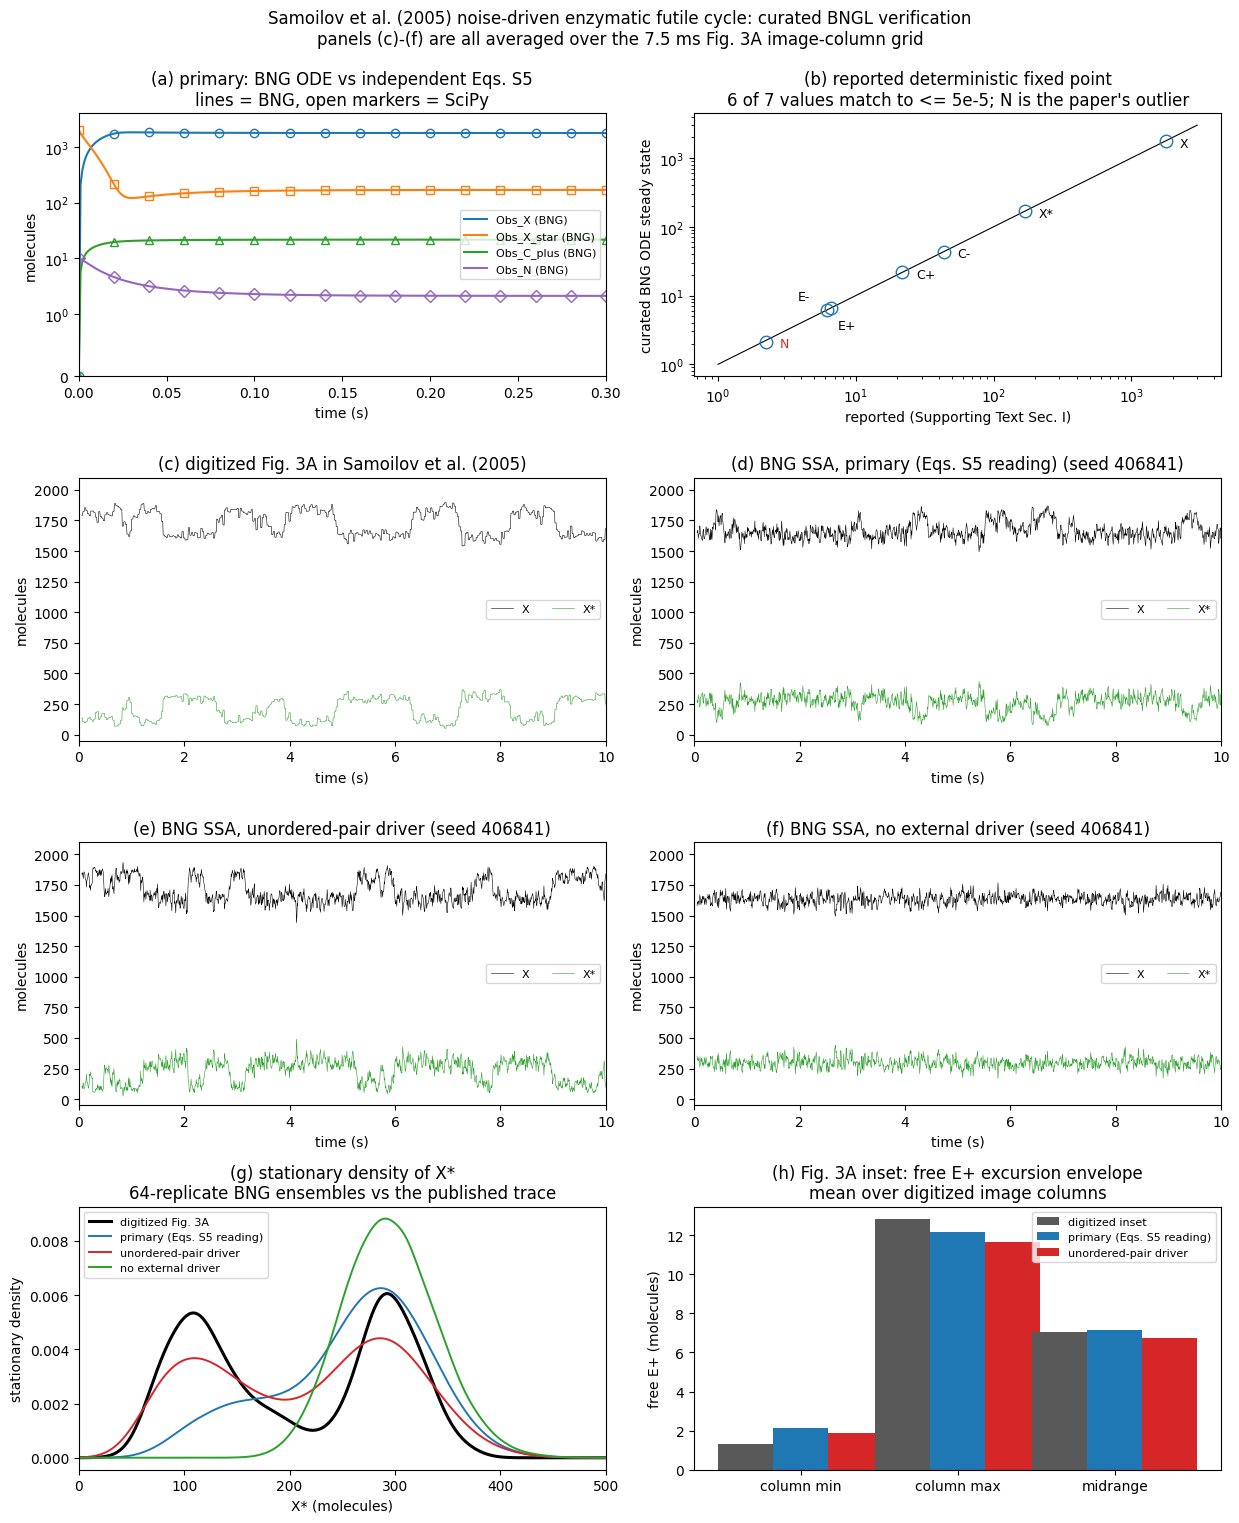

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(12.5, 15.5))
COLORS = {"primary": "tab:blue", "unordered_pair": "tab:red", "no_driver": "tab:green"}
LABELS = {"primary": "primary (Eqs. S5 reading)", "unordered_pair": "unordered-pair driver",
          "no_driver": "no external driver"}

# (a) BNG ODE against the independent Eqs. S5 integration, through the transient
ax = axes[0, 0]
header, bng, sol = transient["primary"]
for obs, sp, colour, marker in [("Obs_X", "X", "tab:blue", "o"),
                                ("Obs_X_star", "Xs", "tab:orange", "s"),
                                ("Obs_C_plus", "Cp", "tab:green", "^"),
                                ("Obs_N", "N", "tab:purple", "D")]:
    ax.plot(bng[:, 0], bng[:, header.index(obs)], "-", lw=1.5, color=colour, label=f"{obs} (BNG)")
    ax.plot(sol.t[::20], sol.y[SPECIES.index(sp)][::20], marker, mfc="none", mec=colour, ms=6)
ax.set_xlim(0, 0.3)
ax.set_yscale("symlog", linthresh=1.0)
ax.set_ylim(0, 4000)
ax.set_xlabel("time (s)")
ax.set_ylabel("molecules")
ax.set_title("(a) primary: BNG ODE vs independent Eqs. S5\nlines = BNG, open markers = SciPy")
ax.legend(fontsize=8, loc="center right")

# (b) reported fixed point
ax = axes[0, 1]
ax.loglog([1, 3000], [1, 3000], "k-", lw=0.8)
ax.plot(reported["reported"], reported["bng"], "o", mfc="none", mec="tab:blue", ms=9)
LABEL_OFFSET = {"X": (10, -4), "X*": (10, -4), "C+": (10, -4), "C-": (10, -4),
                "E+": (8, -14), "E-": (-24, 6), "N": (10, -4)}
for row in reported.itertuples():
    ax.annotate(row.symbol, (row.reported, row.bng), textcoords="offset points",
                xytext=LABEL_OFFSET[row.symbol], fontsize=9,
                color="tab:red" if row.rel_err > 5e-4 else "black")
ax.set_xlabel("reported (Supporting Text Sec. I)")
ax.set_ylabel("curated BNG ODE steady state")
ax.set_title("(b) reported deterministic fixed point\n6 of 7 values match to <= 5e-5; N is the "
             "paper's outlier")

# (c)-(f) trajectories on a common scale
def trace_panel(ax, t, x, xstar, title):
    ax.plot(t, x, "k-", lw=0.4, label="X")
    ax.plot(t, xstar, "-", color="tab:green", lw=0.4, label="X*")
    ax.set_ylim(-50, 2100)
    ax.set_xlim(0, 10)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("molecules")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="center right", ncol=2)


trace_dt = float(np.diff(traces["t"].to_numpy()).mean())
edges_traces = np.r_[traces["t"].to_numpy() - trace_dt / 2,
                     traces["t"].to_numpy()[-1] + trace_dt / 2]


# Average a trajectory over the digitized image columns, as the plotted ink is
def to_column_grid(t, y):
    column = np.digitize(t, edges_traces) - 1
    keep = (column >= 0) & (column < len(traces))
    total = np.bincount(column[keep], weights=y[keep], minlength=len(traces))
    count = np.bincount(column[keep], minlength=len(traces))
    return np.where(count > 0, total / np.maximum(count, 1), np.nan)


trace_panel(axes[1, 0], traces["t"], traces["X_mid"], traces["Xstar_mid"],
            "(c) digitized Fig. 3A in Samoilov et al. (2005)")
for (row, col), key, tag in [((1, 1), "primary", "(d)"), ((2, 0), "unordered_pair", "(e)"),
                             ((2, 1), "no_driver", "(f)")]:
    header, runs = read_gdat(REFERENCE_DIR / f"{VARIANTS[key]}_ssa.gdat")
    trace_panel(axes[row, col], traces["t"],
                to_column_grid(runs[:, 0], runs[:, header.index("Obs_X")]),
                to_column_grid(runs[:, 0], runs[:, header.index("Obs_X_star")]),
                f"{tag} BNG SSA, {LABELS[key]} (seed {BNG_SEED})")

# (g) stationary densities of X*
ax = axes[3, 0]
ax.plot(GRID, published_density, "k-", lw=2.2, label="digitized Fig. 3A")
for key in VARIANTS:
    ax.plot(GRID, model_density[key][1], "-", lw=1.4, color=COLORS[key], label=LABELS[key])
ax.set_xlim(0, 500)
ax.set_xlabel("X* (molecules)")
ax.set_ylabel("stationary density")
ax.set_title("(g) stationary density of X*\n64-replicate BNG ensembles vs the published trace")
ax.legend(fontsize=8)

# (h) E+ envelope
ax = axes[3, 1]
width = 0.35
for i, (name, value) in enumerate(published_inset.items()):
    ax.bar(i - width, value, width, color="0.35", label="digitized inset" if i == 0 else None)
    for j, key in enumerate(DRIVEN):
        ax.bar(i + j * width, model_inset[key][name], width, color=COLORS[key],
               label=LABELS[key] if i == 0 else None)
ax.set_xticks(range(3))
ax.set_xticklabels(["column min", "column max", "midrange"])
ax.set_ylabel("free E+ (molecules)")
ax.set_title("(h) Fig. 3A inset: free E+ excursion envelope\nmean over digitized image columns")
ax.legend(fontsize=8)

fig.suptitle("Samoilov et al. (2005) noise-driven enzymatic futile cycle: curated BNGL "
             "verification\npanels (c)-(f) are all averaged over the 7.5 ms Fig. 3A "
             "image-column grid", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.985))
fig.savefig(MODEL_DIR / "verify_samoilov2005.png", dpi=130)
print(f"Wrote {MODEL_DIR / 'verify_samoilov2005.png'}")

## 8. Summary

| check | result |
|---|---|
| Fresh BioNetGen run reproduces the committed reference for all three files | pass |
| BNG ODE vs independent SciPy integration of Eqs. S5, on the committed grid and through the transient | pass, max relative error < 1e-6 |
| BNG SSA vs independent pure-Python Gillespie of Expressions 7 and 8 | pass, every stationary mean within 3 combined standard errors |
| Reported fixed point of Supporting Text Sec. I, six of seven values | pass, relative error <= 5e-5 |
| Reported fixed point, seventh value (N) | the reported 2.213 violates the paper's own conserved pool `E+ + C+ + N = 30`, which N = 2.132 satisfies exactly |
| Digitized Fig. 3A time averages and low-state occupancy | matched by the unordered-pair variant (all statistics inside the ensemble's central 95%); the primary model spends too little time in the low state |
| Digitized Fig. 3A X* density modes | both modes matched by the unordered-pair variant to within 15 molecules; the primary model has a low-state shoulder instead of a second mode |
| Digitized Fig. 3A E+ inset envelope | midrange matched to 1% (primary) and 4% (unordered pair), column maxima to 5% and 9%; the column minima sit 0.6-0.8 molecules high for both, within the resolution of a saturated plotted trace |
| Fig. 4B claim that removing the driver removes the bistability | pass, checked as unimodality plus loss of the slow trace-to-trace spread |

Not reproduced, and why:

* **Figs. 3B, 4A and 4B panels themselves.** All three are three-dimensional
  perspective surfaces or waterfalls of overlapping curves with no per-curve
  axis, so no reproducible per-curve axis calibration is available.
* **Fig. 5 power-law exponents (p = 0.96 and p = 0.71).** These come from a
  scatter of `std(E+)` against `E+` "with varied cycle-driver coupling"; the
  paper does not say which coupling parameters were varied or over what range,
  so any reproduction would be a guess at the protocol rather than a check of
  the model.